# Case Study A -- Coherence of the Embedded Knowledge Topology

Quantitative companion to Sec. V-A / Fig. 13, for the event `Link_Down(Berlin, Hamburg)` (L1).

## What is claimed, and what is not

This notebook does **not** claim to predict which links a failure will disturb. That was tested and
rejected: across all 26 single-link failure scenarios on germany17 with traffic rerouted on the real
SNDlib matrix, plain hop distance from the failed link attains a mean Spearman of 0.598 against link
disturbance, and no grounding beat it -- node geometry 0.469, node geometry plus `act0`/`act1` 0.461,
shared-route volume 0.332. Which links are disturbed is, on this network, predominantly a
topological fact; the demand matrix adds little on top. (Read positively, this is empirical support
for the 1-hop spreading rule the paper injects.)

What the method does provide is a **grounding that is simultaneously faithful to the data and
logically coherent**. A plain MLP fitted to the same facts has no reason to be symmetric or
anti-reflexive anywhere it was not supervised; the LTN does, by construction. That difference is
measurable, and it is the reason to use a neuro-symbolic grounding rather than a network.

## Design

Three predicates share the node groundings `(lon, lat, act0)` and are trained under one optimizer,
following `knowledge_embedding.ipynb`:

| predicate | target | level |
| --- | --- | --- |
| `Link_geo(a,b)` | normalised `w_g` (geographic separation) | geography |
| `Link_dem(a,b)` | `rho(l) = w1/w0` (retained load) | demand |
| `Node_dem(v)` | `DF1(v) = act1/act0` (retained activity) | demand |

`act0` is in the grounding and the targets involve `act1`, so no target is trivially derivable from
its own input.

**Both variants receive identical supervision**: one orientation per link (the canonical sorted
pair) and all 17 nodes, as a mean-squared-error term. The LTN adds one extra term, `1 - SatAgg` over
axioms that are *exactly* true of the targets:

* `Forall n: Not(Link_geo(n,n))` -- geographic separation of a node from itself is zero.
* `Forall n,m: Link_geo(n,m) <-> Link_geo(m,n)` and the same for `Link_dem` -- both targets are
  symmetric by construction.

Symmetry uses `Equiv(and_op=AndProd, implies_op=ImpliesLuk)`. This matters: a one-way
`Implies` under Reichenbach has `d(sat)/d(P) <= 0` everywhere, so it does not express symmetry at
all -- it is a monotone downward force on the predicate, maximised by the degenerate assignment
`P = 0`. The Lukasiewicz equivalence has its optimum exactly on `P(a,b) = P(b,a)`.

The comparison is therefore an exact ablation: same features, same facts, same architecture, same
seeds, one additional loss term.

In [1]:
import os, math, itertools, random
import numpy as np
import pandas as pd
import networkx as nx
import torch
import ltn
from scipy.stats import spearmanr

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print("device:", device)

device: cpu


In [2]:
# ----------------------------- Topology (germany17 / SNDlib, ref [27]) -----------------------------
raw_nodes = {
    "Hannover": (9.80, 52.39), "Frankfurt": (8.66, 50.14), "Hamburg": (10.08, 53.55),
    "Norden": (7.21, 53.60), "Bremen": (8.80, 53.08), "Berlin": (13.48, 52.52),
    "Muenchen": (11.55, 48.15), "Ulm": (9.99, 48.40), "Nuernberg": (11.08, 49.45),
    "Stuttgart": (9.12, 48.73), "Karlsruhe": (8.41, 49.01), "Mannheim": (8.49, 49.49),
    "Essen": (7.00, 51.44), "Dortmund": (7.48, 51.51), "Duesseldorf": (6.78, 51.22),
    "Koeln": (7.01, 50.92), "Leipzig": (12.38, 51.34),
}
raw_links = {
    "L1": ("Berlin","Hamburg"), "L2": ("Berlin","Hannover"), "L3": ("Berlin","Leipzig"),
    "L4": ("Bremen","Hamburg"), "L5": ("Bremen","Hannover"), "L6": ("Bremen","Norden"),
    "L7": ("Dortmund","Essen"), "L8": ("Dortmund","Hannover"), "L9": ("Dortmund","Koeln"),
    "L10": ("Dortmund","Norden"), "L11": ("Duesseldorf","Essen"), "L12": ("Duesseldorf","Koeln"),
    "L13": ("Frankfurt","Hannover"), "L14": ("Frankfurt","Koeln"), "L15": ("Frankfurt","Leipzig"),
    "L16": ("Frankfurt","Mannheim"), "L17": ("Frankfurt","Nuernberg"), "L18": ("Hamburg","Hannover"),
    "L19": ("Hannover","Leipzig"), "L20": ("Karlsruhe","Mannheim"), "L21": ("Karlsruhe","Stuttgart"),
    "L22": ("Leipzig","Nuernberg"), "L23": ("Muenchen","Nuernberg"), "L24": ("Muenchen","Ulm"),
    "L25": ("Nuernberg","Stuttgart"), "L26": ("Stuttgart","Ulm"),
}
def key(e):
    return tuple(sorted(e))

nodes     = list(raw_nodes.keys())
links     = [key(v) for v in raw_links.values()]
link_name = {key(v): k for k, v in raw_links.items()}
LINKSET   = set(links)
print(f"{len(nodes)} nodes, {len(links)} links")

17 nodes, 26 links


In [3]:
# ----------------------------- Configuration -----------------------------
CONFIG = dict(
    down_link    = ("Berlin", "Hamburg"),   # L1, the scenario of Fig. 13
    beta         = 0.5,                     # tier-2 suppression factor (demand_factor.ipynb)
    seeds        = [0, 1, 2, 3, 4],
    epochs       = 2000,
    lr           = 0.001,
    hidden       = (32, 32),
    # Weight on the (1 - SatAgg) term. 0.0 IS the plain-MLP baseline: the loss reduces to the
    # supervision MSE, so the sweep below is a continuous ablation rather than two discrete conditions.
    lambda_grid  = [0.0, 0.01, 0.1, 1.0],
    lambda_logic = 1.0,                     # used only by single-run calls
    demand_matrix = "demandMatrix-germany17-DFN-5min-20050215-0000.txt",
    demand_file   = None,
    quick_test   = False,                   # True -> 2 seeds x 300 epochs
)
if CONFIG["quick_test"]:
    CONFIG.update(epochs=300, seeds=[0, 1], lambda_grid=[0.0, 1.0])
CONFIG

{'down_link': ('Berlin', 'Hamburg'),
 'beta': 0.5,
 'seeds': [0, 1, 2, 3, 4],
 'epochs': 2000,
 'lr': 0.001,
 'hidden': (32, 32),
 'lambda_grid': [0.0, 0.01, 0.1, 1.0],
 'lambda_logic': 1.0,
 'demand_matrix': 'demandMatrix-germany17-DFN-5min-20050215-0000.txt',
 'demand_file': None,
 'quick_test': False}

In [4]:
# ----------------------------- Demand loader (real SNDlib matrix required) -----------------------------
ARCHIVE_DIR = "directed-nobel-germany-DFN-aggregated-5min-over-1day-native"
DEMAND_DIR_CANDIDATES = [os.path.join(".", ARCHIVE_DIR),
                         os.path.join(".", "Germany17", ARCHIVE_DIR), "."]

def parse_sndlib_demands(filepath):
    """SNDlib native format:  <id> ( <src> <dst> ) <routing_unit> <value> <max_path_length>"""
    out, in_section = [], False
    with open(filepath) as f:
        for line in f:
            s = line.strip()
            if s == "DEMANDS (":
                in_section = True;  continue
            if in_section and s == ")":
                in_section = False; continue
            if in_section and s:
                p = s.split()
                if len(p) >= 7 and p[1] == "(" and p[4] == ")":
                    out.append((p[2], p[3], float(p[6])))
    return out

def load_demands(cfg):
    fp = cfg.get("demand_file") or next(
        (c for c in (os.path.join(d, cfg["demand_matrix"]) for d in DEMAND_DIR_CANDIDATES)
         if os.path.exists(c)), None)
    if not fp or not os.path.exists(fp):
        raise FileNotFoundError(
            f"Real SNDlib demand matrix {cfg['demand_matrix']!r} not found in "
            f"{DEMAND_DIR_CANDIDATES}. Download "
            "'directed-nobel-germany-DFN-aggregated-5min-over-1day-native.tgz' from "
            "https://sndlib.put.poznan.pl/dynamicmatrices.overview.action and extract it beside "
            "this notebook. Uniform synthetic demand is not an acceptable substitute.")
    raw = parse_sndlib_demands(fp)
    unknown = {n for (s, t, _) in raw for n in (s, t)} - set(raw_nodes)
    if unknown:
        raise ValueError(f"demand file references unknown nodes: {sorted(unknown)}")
    demands = [(s, t, v) for (s, t, v) in raw if v > 0 and s != t]
    print(f"Loaded {len(demands)} directed demands (total volume "
          f"{sum(v for *_, v in demands):.2f}) from {os.path.basename(fp)}")
    return demands, os.path.basename(fp)

DEMANDS, DEMAND_SOURCE = load_demands(CONFIG)

Loaded 251 directed demands (total volume 3512.47) from demandMatrix-germany17-DFN-5min-20050215-0000.txt


In [5]:
# ----------------------------- KT0 / KT1 targets (same pipeline as demand_factor.ipynb) -----------------------------
def geo_dist(a, b):
    (x1, y1), (x2, y2) = raw_nodes[a], raw_nodes[b]
    return math.hypot(x2 - x1, y2 - y1)

G0 = nx.Graph(); G0.add_nodes_from(nodes)
for (a, b) in links:
    G0.add_edge(a, b, w_g=geo_dist(a, b))
ROUTES = {(s, t): nx.shortest_path(G0, s, t, weight="w_g") for (s, t, v) in DEMANDS}

def compute_kt(demand_list):
    w   = {d: 0.0 for pair in links for d in (pair, pair[::-1])}
    act = {n: 0.0 for n in raw_nodes}
    for (s, t, v) in demand_list:
        p = ROUTES[(s, t)]
        for (a, b) in zip(p, p[1:]):
            w[(a, b)] += v
        act[s] += v; act[t] += v
        for n in p[1:-1]:
            act[n] += v
    return w, act

w0, act0 = compute_kt(DEMANDS)
DOWN, down_set = key(CONFIG["down_link"]), frozenset(key(CONFIG["down_link"]))
affected_link_set = {frozenset(l) for l in links if l[0] in DOWN or l[1] in DOWN} - {down_set}

def suppression(path, beta):
    edges = {frozenset(e) for e in zip(path, path[1:])}
    if down_set in edges:            return 0.0        # tier 1
    if edges & affected_link_set:    return 1.0 - beta # tier 2
    return 1.0

F = {(s, t): suppression(ROUTES[(s, t)], CONFIG["beta"]) for (s, t, v) in DEMANDS}
w1, act1 = compute_kt([(s, t, v * F[(s, t)]) for (s, t, v) in DEMANDS])

# ---- targets, all in [0,1] and all exactly symmetric where used ----
_wgmax  = max(geo_dist(a, b) for (a, b) in links)
TGT_GEO = {key((a, b)): geo_dist(a, b) / _wgmax for (a, b) in links}          # geographic separation
TGT_DEM = {}                                                                  # retained load
for (a, b) in links:
    num, den = w1[(a, b)] + w1[(b, a)], w0[(a, b)] + w0[(b, a)]
    TGT_DEM[key((a, b))] = num / den if den > 0 else 1.0
TGT_NODE = {n: (act1[n] / act0[n] if act0[n] > 0 else 1.0) for n in nodes}

assert abs(TGT_DEM[DOWN]) < 1e-12, "rho on the down link must be exactly 0"
print(f"w_g/max  : [{min(TGT_GEO.values()):.3f}, {max(TGT_GEO.values()):.3f}]")
print(f"rho      : [{min(TGT_DEM.values()):.3f}, {max(TGT_DEM.values()):.3f}]  "
      f"distinct {len(set(np.round(list(TGT_DEM.values()),6)))}")
print(f"DF1      : [{min(TGT_NODE.values()):.3f}, {max(TGT_NODE.values()):.3f}]  "
      f"distinct {len(set(np.round(list(TGT_NODE.values()),6)))}")

# ---- node groundings: geography + pre-event demand level ----
_xy  = np.array([raw_nodes[n] for n in nodes], dtype=np.float64)
_xy  = (_xy - _xy.mean(0)) / _xy.std(0)
_a0  = np.array([act0[n] for n in nodes], dtype=np.float64); _a0 = _a0 / _a0.max()
NODE_FEAT = {n: np.concatenate([_xy[i], [_a0[i]]]) for i, n in enumerate(nodes)}
NODE_DIM, LINK_DIM = 3, 6

w_g/max  : [0.080, 1.000]
rho      : [0.000, 1.000]  distinct 21
DF1      : [0.493, 1.000]  distinct 17


In [6]:
# ----------------------------- Predicates, axioms, training -----------------------------
class MLP(torch.nn.Module):
    """Same architecture as knowledge_embedding.ipynb, with a configurable input width."""
    def __init__(self, in_dim, hidden):
        super().__init__()
        sizes = (in_dim,) + tuple(hidden) + (1,)
        self.elu, self.sigmoid = torch.nn.ELU(), torch.nn.Sigmoid()
        self.linear_layers = torch.nn.ModuleList(
            [torch.nn.Linear(sizes[i-1], sizes[i]) for i in range(1, len(sizes))])
    def forward(self, *x):
        x = list(x)
        x = x[0] if len(x) == 1 else torch.cat(x, dim=1)
        for layer in self.linear_layers[:-1]:
            x = self.elu(layer(x))
        return self.sigmoid(self.linear_layers[-1](x))

Not    = ltn.Connective(ltn.fuzzy_ops.NotStandard())
# Symmetry MUST be an equivalence, not a one-way implication. Under Reichenbach,
# d/dP Implies(P(n,m), P(m,n)) = P(m,n) - 1 <= 0 everywhere: the formula is maximised by P = 0 and
# expresses no symmetry at all. The Lukasiewicz equivalence is maximised exactly on P(a,b)=P(b,a).
Equiv  = ltn.Connective(ltn.fuzzy_ops.Equiv(and_op=ltn.fuzzy_ops.AndProd(),
                                            implies_op=ltn.fuzzy_ops.ImpliesLuk()))
Forall = ltn.Quantifier(ltn.fuzzy_ops.AggregPMeanError(p=2), quantifier="f")
SatAgg = ltn.fuzzy_ops.SatAgg()

def _T(a):
    return torch.tensor(np.asarray(a, dtype=np.float32), device=device)

def _pair(a, b):
    return np.concatenate([NODE_FEAT[a], NODE_FEAT[b]])

# Supervision is identical for both variants: ONE orientation per link (canonical sorted pair),
# plus all 17 nodes. Symmetry is therefore never handed to either model as data -- it is the
# axioms' job in the LTN variant, and simply absent in the MLP variant.
X_GEO  = _T([_pair(a, b) for (a, b) in links])
Y_GEO  = _T([TGT_GEO[key((a, b))] for (a, b) in links])
X_DEM  = X_GEO
Y_DEM  = _T([TGT_DEM[key((a, b))] for (a, b) in links])
X_NODE = _T([NODE_FEAT[n] for n in nodes])
Y_NODE = _T([TGT_NODE[n] for n in nodes])

def train(seed, cfg, use_logic, geo_only=False):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    Lg = MLP(LINK_DIM, cfg["hidden"]).to(device)
    Ld = MLP(LINK_DIM, cfg["hidden"]).to(device)
    Nd = MLP(NODE_DIM, cfg["hidden"]).to(device)
    P_geo, P_dem, P_node = ltn.Predicate(model=Lg), ltn.Predicate(model=Ld), ltn.Predicate(model=Nd)

    nvar = ltn.Variable("n", _T([NODE_FEAT[n] for n in nodes]))
    mvar = ltn.Variable("m", _T([NODE_FEAT[n] for n in nodes]))

    params = list(Lg.parameters()) + ([] if geo_only else
                                      list(Ld.parameters()) + list(Nd.parameters()))
    opt = torch.optim.Adam(params, lr=cfg["lr"])

    for _ in range(cfg["epochs"]):
        opt.zero_grad()
        sup = ((Lg(X_GEO).reshape(-1) - Y_GEO) ** 2).mean()
        if not geo_only:
            sup = sup + ((Ld(X_DEM).reshape(-1)  - Y_DEM)  ** 2).mean() \
                      + ((Nd(X_NODE).reshape(-1) - Y_NODE) ** 2).mean()
        loss = sup
        if use_logic:
            ax = [Forall(nvar, Not(P_geo(nvar, nvar)), p=5),                        # R1
                  Forall([nvar, mvar], Equiv(P_geo(nvar, mvar), P_geo(mvar, nvar)), p=5)]  # R2
            if not geo_only:
                ax.append(Forall([nvar, mvar],
                                 Equiv(P_dem(nvar, mvar), P_dem(mvar, nvar)), p=5))  # R3
            loss = loss + cfg["lambda_logic"] * (1.0 - SatAgg(*ax))
        loss.backward(); opt.step()

    for m in (Lg, Ld, Nd):
        m.eval()
    with torch.no_grad():
        allp = [(a, b) for a in nodes for b in nodes]           # all 17x17 ordered pairs
        Xall = _T([_pair(a, b) for (a, b) in allp])
        out = dict(
            geo ={p: float(v) for p, v in zip(allp, Lg(Xall).reshape(-1).cpu().numpy())},
            dem ={p: float(v) for p, v in zip(allp, Ld(Xall).reshape(-1).cpu().numpy())},
            node={n: float(v) for n, v in zip(nodes, Nd(X_NODE).reshape(-1).cpu().numpy())})
    return out

In [7]:
# ----------------------------- Metrics -----------------------------
UNORDERED   = [(a, b) for i, a in enumerate(nodes) for b in nodes[i+1:]]   # 136 pairs
UNASSERTED  = [p for p in UNORDERED if key(p) not in LINKSET]              # 110 pairs, never supervised

def _fid(pred, tgt, keys):
    p = np.array([pred[k] for k in keys], dtype=float)
    t = np.array([tgt[k]  for k in keys], dtype=float)
    return spearmanr(p, t).statistic, float(np.abs(p - t).mean())

def measure(out):
    m = {}
    # --- fidelity: does the grounding reproduce what it was taught? ---
    m["geo_rho"],  m["geo_mae"]  = _fid({l: out["geo"][l] for l in links}, TGT_GEO, links)
    m["dem_rho"],  m["dem_mae"]  = _fid({l: out["dem"][l] for l in links}, TGT_DEM, links)
    m["node_rho"], m["node_mae"] = _fid(out["node"], TGT_NODE, nodes)
    # --- coherence: symmetry and anti-reflexivity, on pairs that were never asserted ---
    for tag in ("geo", "dem"):
        d = out[tag]
        m[f"sym_{tag}_all"]  = float(np.mean([abs(d[(a, b)] - d[(b, a)]) for (a, b) in UNORDERED]))
        m[f"sym_{tag}_uns"]  = float(np.mean([abs(d[(a, b)] - d[(b, a)]) for (a, b) in UNASSERTED]))
        m[f"sym_{tag}_max"]  = float(np.max ([abs(d[(a, b)] - d[(b, a)]) for (a, b) in UNORDERED]))
    m["refl_geo"] = float(np.mean([out["geo"][(n, n)] for n in nodes]))
    return m

In [8]:
# ----------------------------- Sweep over lambda_logic -----------------------------
# lambda = 0 is exactly the plain-MLP baseline (the logic term vanishes), so this is one
# continuous ablation: identical features, facts, architecture and seeds throughout, with only
# the weight on the axioms varying.
def label(lam):
    return "0 (MLP, no logic)" if lam == 0 else f"{lam:g}"

rows = []
for lam in CONFIG["lambda_grid"]:
    cfg = {**CONFIG, "lambda_logic": lam}
    for seed in CONFIG["seeds"]:
        out = train(seed, cfg, use_logic=(lam > 0), geo_only=False)
        rows.append(dict(lam=lam, variant=label(lam), seed=seed, setting="joint", **measure(out)))
        g = train(seed, cfg, use_logic=(lam > 0), geo_only=True)
        r, mae = _fid({l: g["geo"][l] for l in links}, TGT_GEO, links)
        rows.append(dict(lam=lam, variant=label(lam), seed=seed, setting="geo_only",
                         geo_rho=r, geo_mae=mae))
    print(f"lambda={lam:g} done")

results = pd.DataFrame(rows)
print("collected", len(results), "rows")
results.head()

lambda=0 done
lambda=0.01 done
lambda=0.1 done
lambda=1 done
collected 40 rows


,lam,variant,seed,setting,geo_rho,geo_mae,dem_rho,dem_mae,node_rho,node_mae,sym_geo_all,sym_geo_uns,sym_geo_max,sym_dem_all,sym_dem_uns,sym_dem_max,refl_geo
0,0.0,"0 (MLP, no logic)",0,joint,0.999316,0.002288,0.809804,0.007662,0.732843,0.019566,0.239760,0.260645,0.855068,0.199818,0.213907,0.967042,0.288869
1,0.0,"0 (MLP, no logic)",0,geo_only,0.999316,0.002288,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,"0 (MLP, no logic)",1,joint,0.999316,0.002282,0.796781,0.012672,0.774510,0.017998,0.183553,0.189055,0.650526,0.406410,0.442728,0.994284,0.298515
3,0.0,"0 (MLP, no logic)",1,geo_only,0.999316,0.002282,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,"0 (MLP, no logic)",2,joint,0.998632,0.002047,0.756342,0.016598,0.784314,0.017810,0.175833,0.178099,0.692872,0.389951,0.438374,0.989152,0.285904


In [9]:
# ----------------------------- Results -----------------------------
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
joint    = results[results["setting"] == "joint"]
VARIANTS = [label(l) for l in CONFIG["lambda_grid"]]          # column order, lambda ascending

def cell(v, col):
    s = joint.loc[joint["variant"] == v, col].dropna()
    return f"{s.mean():.4f} +/- {s.std():.4f}" if len(s) else "n/a"

ROWS = [
    ("Fidelity  Link_geo  Spearman",  "geo_rho"),
    ("Fidelity  Link_geo  MAE",       "geo_mae"),
    ("Fidelity  Link_dem  Spearman",  "dem_rho"),
    ("Fidelity  Link_dem  MAE",       "dem_mae"),
    ("Fidelity  Node_dem  Spearman",  "node_rho"),
    ("Fidelity  Node_dem  MAE",       "node_mae"),
    ("Coherence sym. violation  Link_geo, all pairs",      "sym_geo_all"),
    ("Coherence sym. violation  Link_geo, never asserted", "sym_geo_uns"),
    ("Coherence sym. violation  Link_geo, worst pair",     "sym_geo_max"),
    ("Coherence sym. violation  Link_dem, all pairs",      "sym_dem_all"),
    ("Coherence sym. violation  Link_dem, never asserted", "sym_dem_uns"),
    ("Coherence anti-reflexivity  Link_geo(n,n)",          "refl_geo"),
]
summary = pd.DataFrame([{"Metric": lab, **{v: cell(v, c) for v in VARIANTS}} for lab, c in ROWS])
assert (summary[VARIANTS[0]] != "n/a").all(), "empty selection -- check column indexing"
print(f"columns = lambda_logic; {len(CONFIG['seeds'])} seeds, mean +/- std.")
print("Fidelity: higher Spearman / lower MAE better.  Coherence: lower better (0 = axiom exact).\n")
summary

columns = lambda_logic; 5 seeds, mean +/- std.
Fidelity: higher Spearman / lower MAE better.  Coherence: lower better (0 = axiom exact).



,Metric,"0 (MLP, no logic)",0.01,0.1,1
0,Fidelity Link_geo Spearman,0.9992 +/- 0.0003,0.9996 +/- 0.0004,0.9967 +/- 0.0007,0.9608 +/- 0.0309
1,Fidelity Link_geo MAE,0.0021 +/- 0.0002,0.0033 +/- 0.0003,0.0120 +/- 0.0009,0.1092 +/- 0.0155
2,Fidelity Link_dem Spearman,0.7879 +/- 0.0271,0.9000 +/- 0.0192,0.8777 +/- 0.0186,0.7764 +/- 0.0090
3,Fidelity Link_dem MAE,0.0113 +/- 0.0039,0.0101 +/- 0.0024,0.0139 +/- 0.0033,0.0623 +/- 0.0013
4,Fidelity Node_dem Spearman,0.7603 +/- 0.0200,0.7603 +/- 0.0200,0.7603 +/- 0.0200,0.7603 +/- 0.0200
5,Fidelity Node_dem MAE,0.0191 +/- 0.0015,0.0191 +/- 0.0015,0.0191 +/- 0.0015,0.0191 +/- 0.0015
6,"Coherence sym. violation Link_geo, all pairs",0.2097 +/- 0.0333,0.0291 +/- 0.0055,0.0065 +/- 0.0009,0.0022 +/- 0.0008
7,"Coherence sym. violation Link_geo, never asse...",0.2195 +/- 0.0415,0.0241 +/- 0.0058,0.0050 +/- 0.0008,0.0019 +/- 0.0007
8,"Coherence sym. violation Link_geo, worst pair",0.7627 +/- 0.0875,0.1195 +/- 0.0249,0.0245 +/- 0.0021,0.0097 +/- 0.0044
9,"Coherence sym. violation Link_dem, all pairs",0.3014 +/- 0.1186,0.0584 +/- 0.0166,0.0090 +/- 0.0029,0.0014 +/- 0.0003


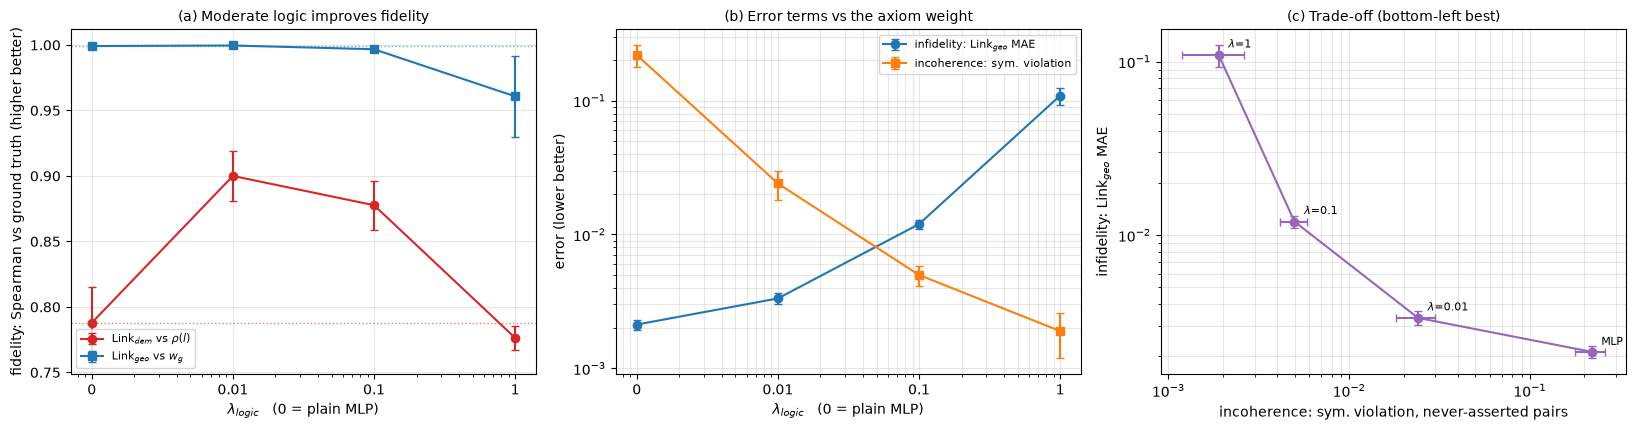

lambda=0.01  Link_dem Spearman 0.9000 vs MLP 0.7879  (diff +0.1121, better on 5/5 seeds)
lambda=0.1   Link_dem Spearman 0.8777 vs MLP 0.7879  (diff +0.0898, better on 5/5 seeds)
lambda=1     Link_dem Spearman 0.7764 vs MLP 0.7879  (diff -0.0115, better on 2/5 seeds)


In [13]:
# ----------------------------- Fidelity / coherence vs the weight on the axioms -----------------------------
# Three views of the same sweep. lambda = 0 is the plain-MLP baseline, so every curve starts from it.
#
# The relationship is not a simple trade-off. Symmetry is quantified over all 289 node pairs while
# supervision covers 26 links in one orientation, so at moderate weight the axioms act as a
# structural regulariser and *improve* fidelity on the harder predicate; only when the logic term
# overwhelms the data does the fit degrade. Panel (a) is the one that shows this, and it is the
# result a trade-off plot alone would conceal.
import matplotlib.pyplot as plt

lams = CONFIG["lambda_grid"]
xs   = [max(l, 1e-3) for l in lams]              # 0 drawn at the axis floor on a log scale
xtl  = [("0" if l == 0 else f"{l:g}") for l in lams]
def ms(col):
    return ([joint.loc[joint["lam"] == l, col].mean() for l in lams],
            [joint.loc[joint["lam"] == l, col].std()  for l in lams])

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.4))

# --- (a) fidelity: rank agreement with the KT1 targets ---
ax = axes[0]
for col, lab, c, mk in [("dem_rho", r"Link$_{dem}$ vs $\rho(l)$", "tab:red",  "o"),
                        ("geo_rho", r"Link$_{geo}$ vs $w_g$",     "tab:blue", "s")]:
    mu, sd = ms(col)
    ax.errorbar(xs, mu, yerr=sd, marker=mk, color=c, capsize=3, label=lab)
    ax.axhline(mu[0], color=c, ls=":", lw=1, alpha=0.6)      # the lambda = 0 (MLP) level
ax.set_xscale("log"); ax.set_xticks(xs); ax.set_xticklabels(xtl)
ax.set_xlabel(r"$\lambda_{logic}$   (0 = plain MLP)")
ax.set_ylabel(r"fidelity: Spearman vs ground truth (higher better)")
ax.set_title("(a) Moderate logic improves fidelity", fontsize=10)
ax.legend(fontsize=8, loc="lower left"); ax.grid(alpha=0.3)

# --- (b) both error types ---
ax = axes[1]
for col, lab, c, mk in [("geo_mae",     "infidelity: Link$_{geo}$ MAE",   "tab:blue",   "o"),
                        ("sym_geo_uns", "incoherence: sym. violation",    "tab:orange", "s")]:
    mu, sd = ms(col)
    ax.errorbar(xs, mu, yerr=sd, marker=mk, color=c, capsize=3, label=lab)
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xticks(xs); ax.set_xticklabels(xtl)
ax.set_xlabel(r"$\lambda_{logic}$   (0 = plain MLP)")
ax.set_ylabel("error (lower better)")
ax.set_title("(b) Error terms vs the axiom weight", fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")

# --- (c) Pareto view ---
ax = axes[2]
fid, fsd = ms("geo_mae"); coh, csd = ms("sym_geo_uns")
ax.errorbar(coh, fid, xerr=csd, yerr=fsd, fmt="o-", color="tab:purple", capsize=3)
for l, x, y in zip(lams, coh, fid):
    ax.annotate(("MLP" if l == 0 else f"$\\lambda$={l:g}"), (x, y),
                textcoords="offset points", xytext=(7, 5), fontsize=8)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("incoherence: sym. violation, never-asserted pairs")
ax.set_ylabel("infidelity: Link$_{geo}$ MAE")
ax.set_title("(c) Trade-off (bottom-left best)", fontsize=10)
ax.grid(alpha=0.3, which="both")

fig.tight_layout()
os.makedirs("img", exist_ok=True)
fig.savefig(os.path.join("img", "coherence_tradeoff.pdf"), bbox_inches="tight")
plt.show()

# --- the numbers behind panel (a), for the caption ---
for l in lams:
    if l == 0:
        continue
    a = joint.loc[joint["lam"] == l].set_index("seed")["dem_rho"]
    b = joint.loc[joint["lam"] == 0].set_index("seed")["dem_rho"]
    d = (a - b).dropna()
    print(f"lambda={l:<5g} Link_dem Spearman {a.mean():.4f} vs MLP {b.mean():.4f}  "
          f"(diff {d.mean():+.4f}, better on {int((d>0).sum())}/{len(d)} seeds)")

In [14]:
# ----------------------------- Two-level coexistence -----------------------------
# Does embedding the demand level degrade the geography level? Compare Link_geo fidelity when
# trained alone against the same predicate trained jointly with Link_dem and Node_dem.
two = (results.pivot_table(index=["variant", "seed"], columns="setting",
                           values=["geo_rho", "geo_mae"])
              .reset_index())
tl = pd.DataFrame([
    dict(Variant=v,
         geo_alone_Spearman = f"{two.loc[two['variant']==v, ('geo_rho','geo_only')].mean():.4f}",
         geo_joint_Spearman = f"{two.loc[two['variant']==v, ('geo_rho','joint')].mean():.4f}",
         geo_alone_MAE      = f"{two.loc[two['variant']==v, ('geo_mae','geo_only')].mean():.4f}",
         geo_joint_MAE      = f"{two.loc[two['variant']==v, ('geo_mae','joint')].mean():.4f}")
    for v in VARIANTS])
tl

,Variant,geo_alone_Spearman,geo_joint_Spearman,geo_alone_MAE,geo_joint_MAE
0,"0 (MLP, no logic)",0.9992,0.9992,0.0021,0.0021
1,0.01,0.9996,0.9996,0.0042,0.0033
2,0.1,0.9969,0.9967,0.0154,0.0120
3,1,0.9285,0.9608,0.1291,0.1092


In [15]:
# ----------------------------- Save -----------------------------
results.to_csv("coherence_raw.csv", index=False)
summary.to_csv("coherence_summary.csv", index=False)
tl.to_csv("coherence_twolevel.csv", index=False)
print("saved coherence_{raw,summary,twolevel}.csv")

saved coherence_{raw,summary,twolevel}.csv


## Notes for the write-up

* **The claim.** Both variants are given identical features, identical facts, identical
  architecture and identical seeds; the LTN differs by a single additional loss term. Any gap is
  therefore attributable to the injected axioms and to nothing else. The claim is that the
  neuro-symbolic grounding is **coherent as well as faithful** -- it respects the structural
  properties of the knowledge topology on regions where it was never supervised -- and that this
  costs nothing in fidelity. If a fidelity cost does appear, it should be reported as a trade-off
  rather than suppressed.

* **Why "never asserted" is the column that matters.** Supervision covers 26 links in one
  orientation. The `_uns` columns are the 110 node pairs that are not links and were never
  mentioned in any fact. An unconstrained network is free to behave arbitrarily there; the
  quantified axioms are not. Reporting symmetry violation only over asserted links would understate
  the difference, because a network can memorise 26 points.

* **What is deliberately not claimed.** Nothing here predicts which links a failure disturbs. That
  framing was tested and rejected: over all 26 single-link failures with traffic rerouted on the
  real matrix, hop distance alone reaches mean Spearman 0.598, while node-geometry grounding reaches
  0.469, node geometry plus `act0`/`act1` 0.461, and shared-route volume 0.332 -- none of them
  better, and the demand features not better than geometry alone (paired Wilcoxon p = 0.85). Link
  disturbance on germany17 is predominantly topological. Stating this plainly is stronger than
  omitting it, and it doubles as empirical justification for the 1-hop spreading rule the paper
  injects.

* **On the symmetry operator.** `Implies` under Reichenbach has `d(sat)/dP <= 0` for all inputs, so
  `Forall n,m: Implies(P(n,m), P(m,n))` is maximised by `P = 0` and encodes no symmetry whatever --
  it is a uniform downward force on the predicate. Quantified over all 289 node pairs against a few
  dozen supervised facts, it will dominate the objective and invert the grounding. The Lukasiewicz
  equivalence used here has its optimum exactly on `P(a,b) = P(b,a)`. This is worth a sentence in
  the paper: the choice of fuzzy operator is not a detail.

* **Ground truth.** KT1 at `beta = 0.5` from `demand_factor.ipynb`, built on the real SNDlib matrix
  (251 directed demands, total volume 3512.47), routed on `w_g`. Since no predictive claim is made,
  the fact that KT1's `rho` correlates with hop distance at 0.806 is immaterial here -- KT1 is the
  knowledge topology being represented, not a phenomenon being forecast.

* **Cost.** `len(seeds) x 2 variants x 2 settings` short runs on a 17-node graph.